# LendingClub discrete-time hazard model project
# File: data/raw/accepted_2007_to_2018Q4.csv.gz
#
# Workflow:
# 1. Load and clean data
# 2. Define event and censoring
# 3. Create duration
# 4. Expand to loan-month panel
# 5. Train/valid/test split
# 6. Logistic hazard model
# 7. Random forest comparison
# 8. Cumulative PD
# 9. Expected loss / reserve / pricing summaries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

In [2]:
DATA_DIR = Path("data")
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

accepted_path = RAW_DIR / "lendingclub" /"accepted_2007_to_2018Q4.csv.gz"

# Runtime controls
USE_SAMPLE = True          # set to False if you want the full dataset
SAMPLE_SIZE = 50000        # increase later if your machine can handle it
RANDOM_STATE = 42

In [3]:
df_raw = pd.read_csv(
    accepted_path,
    low_memory=False,
    compression="gzip"
)

print("Raw shape:", df_raw.shape)
print("First 20 columns:", df_raw.columns.tolist()[:20])

Raw shape: (2260701, 151)
First 20 columns: ['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc']


In [4]:
key_columns = [
    "id",
    "issue_d",
    "loan_status",
    "term",
    "loan_amnt",
    "installment",
    "emp_length",
    "home_ownership",
    "annual_inc",
    "verification_status",
    "purpose",
    "addr_state",
    "dti",
    "delinq_2yrs",
    "inq_last_6mths",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",
    "mort_acc",
    "pub_rec_bankruptcies",
    "fico_range_low",
    "fico_range_high",
    "earliest_cr_line",
    "last_pymnt_d",
    "last_credit_pull_d",
]

missing_cols = [c for c in key_columns if c not in df_raw.columns]
print("Missing columns:", missing_cols)

Missing columns: []


In [5]:
cols = [c for c in key_columns if c in df_raw.columns]
df = df_raw[cols].copy()

print("Working shape:", df.shape)
df.head()

Working shape: (2260701, 27)


,id,issue_d,loan_status,term,loan_amnt,installment,emp_length,home_ownership,annual_inc,verification_status,purpose,addr_state,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies,fico_range_low,fico_range_high,earliest_cr_line,last_pymnt_d,last_credit_pull_d
0,68407277,Dec-2015,Fully Paid,36 months,3600.0,123.03,10+ years,MORTGAGE,55000.0,Not Verified,debt_consolidation,PA,5.91,0.0,1.0,7.0,0.0,2765.0,29.7,13.0,1.0,0.0,675.0,679.0,Aug-2003,Jan-2019,Mar-2019
1,68355089,Dec-2015,Fully Paid,36 months,24700.0,820.28,10+ years,MORTGAGE,65000.0,Not Verified,small_business,SD,16.06,1.0,4.0,22.0,0.0,21470.0,19.2,38.0,4.0,0.0,715.0,719.0,Dec-1999,Jun-2016,Mar-2019
2,68341763,Dec-2015,Fully Paid,60 months,20000.0,432.66,10+ years,MORTGAGE,63000.0,Not Verified,home_improvement,IL,10.78,0.0,0.0,6.0,0.0,7869.0,56.2,18.0,5.0,0.0,695.0,699.0,Aug-2000,Jun-2017,Mar-2019
3,66310712,Dec-2015,Current,60 months,35000.0,829.90,10+ years,MORTGAGE,110000.0,Source Verified,debt_consolidation,NJ,17.06,0.0,0.0,13.0,0.0,7802.0,11.6,17.0,1.0,0.0,785.0,789.0,Sep-2008,Feb-2019,Mar-2019
4,68476807,Dec-2015,Fully Paid,60 months,10400.0,289.91,3 years,MORTGAGE,104433.0,Source Verified,major_purchase,PA,25.37,1.0,3.0,12.0,0.0,21929.0,64.5,35.0,6.0,0.0,695.0,699.0,Jun-1998,Jul-2016,Mar-2018


In [6]:
if USE_SAMPLE:
    df = df.sample(SAMPLE_SIZE, random_state=RANDOM_STATE).copy()

print("Shape after optional sampling:", df.shape)

Shape after optional sampling: (50000, 27)


In [7]:
date_cols = ["issue_d", "earliest_cr_line", "last_pymnt_d", "last_credit_pull_d"]

for c in date_cols:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], format="%b-%Y", errors="coerce")

df["fico_avg"] = (df["fico_range_low"] + df["fico_range_high"]) / 2

df["term_num"] = (
    df["term"]
    .astype(str)
    .str.extract(r"(\d+)")
    .astype(float)
)

df["credit_history_years"] = (
    (df["issue_d"] - df["earliest_cr_line"]).dt.days / 365.25
)

df[["issue_d", "loan_status", "term", "term_num", "fico_avg", "credit_history_years"]].head()

,issue_d,loan_status,term,term_num,fico_avg,credit_history_years
392949,2015-02-01,Current,60 months,60.0,737.0,33.336071
1273506,2014-05-01,Fully Paid,36 months,36.0,687.0,13.081451
324024,2015-04-01,Fully Paid,36 months,36.0,782.0,11.581109
2066630,2017-12-01,Fully Paid,36 months,36.0,742.0,12.501027
477199,2018-02-01,Current,60 months,60.0,717.0,18.590007


In [8]:
status_counts = df["loan_status"].value_counts(dropna=False)
status_counts

loan_status
Fully Paid                                             23771
Current                                                19370
Charged Off                                             6015
Late (31-120 days)                                       505
In Grace Period                                          186
Late (16-30 days)                                        108
Does not meet the credit policy. Status:Fully Paid        24
Does not meet the credit policy. Status:Charged Off       19
NaN                                                        2
Name: count, dtype: int64

In [9]:
# Basic event definition:
# event = 1 for default-like outcomes
# event = 0 otherwise

default_statuses = {
    "Charged Off",
    "Default",
}

df["event"] = df["loan_status"].isin(default_statuses).astype(int)

# Use last payment date if available; otherwise use last credit pull date
df["end_date"] = df["last_pymnt_d"]
mask_missing_end = df["end_date"].isna()
df.loc[mask_missing_end, "end_date"] = df.loc[mask_missing_end, "last_credit_pull_d"]

df[["loan_status", "event", "issue_d", "last_pymnt_d", "last_credit_pull_d", "end_date"]].head()

,loan_status,event,issue_d,last_pymnt_d,last_credit_pull_d,end_date
392949,Current,0,2015-02-01,2019-03-01,2019-03-01,2019-03-01
1273506,Fully Paid,0,2014-05-01,2017-06-01,2017-08-01,2017-06-01
324024,Fully Paid,0,2015-04-01,2017-03-01,2019-02-01,2017-03-01
2066630,Fully Paid,0,2017-12-01,2018-10-01,2018-10-01,2018-10-01
477199,Current,0,2018-02-01,2019-03-01,2019-03-01,2019-03-01


In [10]:
def month_diff(start, end):
    return (end.dt.year - start.dt.year) * 12 + (end.dt.month - start.dt.month)

df = df[df["issue_d"].notna()].copy()
df = df[df["end_date"].notna()].copy()

df["duration_months"] = month_diff(df["issue_d"], df["end_date"])
df["duration_months"] = df["duration_months"].clip(lower=1)

print(df.shape)
df[["id", "issue_d", "end_date", "duration_months", "event"]].head()

(49998, 33)


,id,issue_d,end_date,duration_months,event
392949,39651438,2015-02-01,2019-03-01,49,0
1273506,16411620,2014-05-01,2017-06-01,37,0
324024,45122316,2015-04-01,2017-03-01,23,0
2066630,125356772,2017-12-01,2018-10-01,10,0
477199,128490686,2018-02-01,2019-03-01,13,0


In [11]:
df = df[df["term_num"].isin([36, 60])].copy()
df = df[df["duration_months"] >= 1].copy()
df = df[df["fico_avg"].notna()].copy()

print("After cleaning/filtering:", df.shape)

After cleaning/filtering: (49998, 33)


In [12]:
print("Event rate:")
print(df["event"].value_counts(normalize=True))

print("\nLoan status counts:")
print(df["loan_status"].value_counts(dropna=False).head(20))

print("\nDuration summary:")
print(df["duration_months"].describe())

Event rate:
event
0    0.879695
1    0.120305
Name: proportion, dtype: float64

Loan status counts:
loan_status
Fully Paid                                             23771
Current                                                19370
Charged Off                                             6015
Late (31-120 days)                                       505
In Grace Period                                          186
Late (16-30 days)                                        108
Does not meet the credit policy. Status:Fully Paid        24
Does not meet the credit policy. Status:Charged Off       19
Name: count, dtype: int64

Duration summary:
count    49998.000000
mean        19.577083
std         12.398375
min          1.000000
25%          9.000000
50%         17.000000
75%         29.000000
max         70.000000
Name: duration_months, dtype: float64


In [13]:
loan_level_path = PROCESSED_DIR / "loan_level_survival_base.csv"
df.to_csv(loan_level_path, index=False)
print(f"Saved loan-level base to: {loan_level_path}")

Saved loan-level base to: data/processed/loan_level_survival_base.csv


In [14]:
static_cols = [
    "loan_amnt",
    "term_num",
    "installment",
    "emp_length",
    "home_ownership",
    "annual_inc",
    "verification_status",
    "purpose",
    "addr_state",
    "dti",
    "delinq_2yrs",
    "inq_last_6mths",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",
    "mort_acc",
    "pub_rec_bankruptcies",
    "fico_avg",
    "credit_history_years",
]

def expand_loan(row):
    n = int(row["duration_months"])
    event = int(row["event"])

    out = pd.DataFrame({
        "id": row["id"],
        "issue_d": row["issue_d"],
        "month_on_book": np.arange(1, n + 1),
        "duration_months": row["duration_months"],
        "event": row["event"],
    })

    out["hazard_target"] = 0
    if event == 1:
        out.loc[out["month_on_book"] == n, "hazard_target"] = 1

    for col in static_cols:
        out[col] = row[col]

    return out

In [15]:
panel_parts = []
for _, row in df.iterrows():
    panel_parts.append(expand_loan(row))

panel = pd.concat(panel_parts, ignore_index=True)

print("Panel shape:", panel.shape)
panel.head()

Panel shape: (978815, 27)


,id,issue_d,month_on_book,duration_months,event,hazard_target,loan_amnt,term_num,installment,emp_length,home_ownership,annual_inc,verification_status,purpose,addr_state,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies,fico_avg,credit_history_years
0,39651438,2015-02-01,1,49,0,0,32000.0,60.0,687.65,10+ years,MORTGAGE,120000.0,Verified,debt_consolidation,CA,24.05,0.0,0.0,20.0,0.0,39687.0,57.8,42.0,2.0,0.0,737.0,33.336071
1,39651438,2015-02-01,2,49,0,0,32000.0,60.0,687.65,10+ years,MORTGAGE,120000.0,Verified,debt_consolidation,CA,24.05,0.0,0.0,20.0,0.0,39687.0,57.8,42.0,2.0,0.0,737.0,33.336071
2,39651438,2015-02-01,3,49,0,0,32000.0,60.0,687.65,10+ years,MORTGAGE,120000.0,Verified,debt_consolidation,CA,24.05,0.0,0.0,20.0,0.0,39687.0,57.8,42.0,2.0,0.0,737.0,33.336071
3,39651438,2015-02-01,4,49,0,0,32000.0,60.0,687.65,10+ years,MORTGAGE,120000.0,Verified,debt_consolidation,CA,24.05,0.0,0.0,20.0,0.0,39687.0,57.8,42.0,2.0,0.0,737.0,33.336071
4,39651438,2015-02-01,5,49,0,0,32000.0,60.0,687.65,10+ years,MORTGAGE,120000.0,Verified,debt_consolidation,CA,24.05,0.0,0.0,20.0,0.0,39687.0,57.8,42.0,2.0,0.0,737.0,33.336071


In [16]:
panel["mob_6bin"] = pd.cut(
    panel["month_on_book"],
    bins=[0, 6, 12, 24, 36, 60, 120],
    labels=["1_6", "7_12", "13_24", "25_36", "37_60", "61_plus"]
)

panel["month_on_book_sq"] = panel["month_on_book"] ** 2

panel[["id", "month_on_book", "mob_6bin", "hazard_target"]].head(20)

,id,month_on_book,mob_6bin,hazard_target
0,39651438,1,1_6,0
1,39651438,2,1_6,0
2,39651438,3,1_6,0
3,39651438,4,1_6,0
4,39651438,5,1_6,0
5,39651438,6,1_6,0
6,39651438,7,7_12,0
7,39651438,8,7_12,0
8,39651438,9,7_12,0
9,39651438,10,7_12,0


In [17]:
panel_path = PROCESSED_DIR / "loan_month_panel.csv"
panel.to_csv(panel_path, index=False)
print(f"Saved panel to: {panel_path}")

Saved panel to: data/processed/loan_month_panel.csv


In [18]:
train_panel = panel[panel["issue_d"] < "2016-01-01"].copy()
valid_panel = panel[(panel["issue_d"] >= "2016-01-01") & (panel["issue_d"] < "2017-01-01")].copy()
test_panel  = panel[panel["issue_d"] >= "2017-01-01"].copy()

print("Train shape:", train_panel.shape)
print("Valid shape:", valid_panel.shape)
print("Test shape :", test_panel.shape)

Train shape: (517939, 29)
Valid shape: (218609, 29)
Test shape : (242267, 29)


In [19]:
target = "hazard_target"

numeric_features = [
    "month_on_book",
    "loan_amnt",
    "term_num",
    "installment",
    "annual_inc",
    "dti",
    "delinq_2yrs",
    "inq_last_6mths",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",
    "mort_acc",
    "pub_rec_bankruptcies",
    "fico_avg",
    "credit_history_years",
]

categorical_features = [
    "emp_length",
    "home_ownership",
    "verification_status",
    "purpose",
    "addr_state",
    "mob_6bin",
]

In [20]:
X_train = train_panel[numeric_features + categorical_features]
y_train = train_panel[target]

X_valid = valid_panel[numeric_features + categorical_features]
y_valid = valid_panel[target]

X_test = test_panel[numeric_features + categorical_features]
y_test = test_panel[target]

print(X_train.shape, y_train.shape)
print(X_valid.shape, y_valid.shape)
print(X_test.shape, y_test.shape)

(517939, 23) (517939,)
(218609, 23) (218609,)
(242267, 23) (242267,)


In [21]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

In [43]:
from sklearn.calibration import CalibratedClassifierCV

hazard_base = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

hazard_calibrated = CalibratedClassifierCV(
    estimator=hazard_base,
    method="sigmoid",
    cv=3
)

hazard_calibrated.fit(X_train, y_train)

valid_pred_hazard = hazard_calibrated.predict_proba(X_valid)[:, 1]
test_pred_hazard = hazard_calibrated.predict_proba(X_test)[:, 1]

print("Actual monthly event rate:", y_test.mean())
print("Mean predicted hazard:", test_pred_hazard.mean())

Actual monthly event rate: 0.0045074236276504845
Mean predicted hazard: 0.005745708566672069


In [44]:

hazard_results = {
    "valid_roc_auc": roc_auc_score(y_valid, valid_pred_hazard),
    "valid_pr_auc": average_precision_score(y_valid, valid_pred_hazard),
    "test_roc_auc": roc_auc_score(y_test, test_pred_hazard),
    "test_pr_auc": average_precision_score(y_test, test_pred_hazard),
}

hazard_results

{'valid_roc_auc': 0.6615597480501696,
 'valid_pr_auc': 0.013513316058384364,
 'test_roc_auc': 0.6612786035705078,
 'test_pr_auc': 0.008486871644992396}

In [45]:
rf_model = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        min_samples_leaf=50,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced_subsample"
    )),
])

rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

In [46]:
valid_pred_rf = rf_model.predict_proba(X_valid)[:, 1]
test_pred_rf = rf_model.predict_proba(X_test)[:, 1]

rf_results = {
    "valid_roc_auc": roc_auc_score(y_valid, valid_pred_rf),
    "valid_pr_auc": average_precision_score(y_valid, valid_pred_rf),
    "test_roc_auc": roc_auc_score(y_test, test_pred_rf),
    "test_pr_auc": average_precision_score(y_test, test_pred_rf),
}

rf_results

{'valid_roc_auc': 0.6514503362516443,
 'valid_pr_auc': 0.013209746183818394,
 'test_roc_auc': 0.6701368225085442,
 'test_pr_auc': 0.008597385304114719}

In [47]:
results_df = pd.DataFrame([
    {
        "model": "logistic_hazard",
        **hazard_results
    },
    {
        "model": "random_forest",
        **rf_results
    }
])

results_df

,model,valid_roc_auc,valid_pr_auc,test_roc_auc,test_pr_auc
0,logistic_hazard,0.66156,0.013513,0.661279,0.008487
1,random_forest,0.65145,0.013210,0.670137,0.008597


In [27]:
test_scored = test_panel.copy()
test_scored["pred_hazard_logit"] = test_pred_hazard
test_scored["pred_hazard_rf"] = test_pred_rf

test_scored = test_scored.sort_values(["id", "month_on_book"]).copy()
test_scored.head()

,id,issue_d,month_on_book,duration_months,event,hazard_target,loan_amnt,term_num,installment,emp_length,home_ownership,annual_inc,verification_status,purpose,addr_state,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies,fico_avg,credit_history_years,mob_6bin,month_on_book_sq,pred_hazard_logit,pred_hazard_rf
214997,100001365,2017-03-01,1,24,0,0,20000.0,36.0,683.46,10+ years,MORTGAGE,87000.0,Not Verified,debt_consolidation,MT,25.3,0.0,0.0,12.0,0.0,19262.0,79.3,19.0,1.0,0.0,662.0,12.495551,1_6,1,0.291923,0.072109
214998,100001365,2017-03-01,2,24,0,0,20000.0,36.0,683.46,10+ years,MORTGAGE,87000.0,Not Verified,debt_consolidation,MT,25.3,0.0,0.0,12.0,0.0,19262.0,79.3,19.0,1.0,0.0,662.0,12.495551,1_6,4,0.291697,0.090126
214999,100001365,2017-03-01,3,24,0,0,20000.0,36.0,683.46,10+ years,MORTGAGE,87000.0,Not Verified,debt_consolidation,MT,25.3,0.0,0.0,12.0,0.0,19262.0,79.3,19.0,1.0,0.0,662.0,12.495551,1_6,9,0.291472,0.091965
215000,100001365,2017-03-01,4,24,0,0,20000.0,36.0,683.46,10+ years,MORTGAGE,87000.0,Not Verified,debt_consolidation,MT,25.3,0.0,0.0,12.0,0.0,19262.0,79.3,19.0,1.0,0.0,662.0,12.495551,1_6,16,0.291247,0.085079
215001,100001365,2017-03-01,5,24,0,0,20000.0,36.0,683.46,10+ years,MORTGAGE,87000.0,Not Verified,debt_consolidation,MT,25.3,0.0,0.0,12.0,0.0,19262.0,79.3,19.0,1.0,0.0,662.0,12.495551,1_6,25,0.291022,0.090256


In [50]:
test_scored["survival_prob_logit"] = test_scored.groupby("id")["pred_hazard_logit"].transform(
    lambda x: (1 - x).cumprod()
)
test_scored["cum_pd_logit"] = 1 - test_scored["survival_prob_logit"]

test_scored["survival_prob_rf"] = test_scored.groupby("id")["pred_hazard_rf"].transform(
    lambda x: (1 - x).cumprod()
)
test_scored["cum_pd_rf"] = 1 - test_scored["survival_prob_rf"]

test_scored[[
    "id", "month_on_book", "pred_hazard_logit", "cum_pd_logit",
    "pred_hazard_rf", "cum_pd_rf"
]].head(20)

,id,month_on_book,pred_hazard_logit,cum_pd_logit,pred_hazard_rf,cum_pd_rf
214997,100001365,1,0.291923,0.291923,0.072109,0.072109
214998,100001365,2,0.291697,0.498467,0.090126,0.155736
214999,100001365,3,0.291472,0.644650,0.091965,0.233379
215000,100001365,4,0.291247,0.748145,0.085079,0.298602
215001,100001365,5,0.291022,0.821440,0.090256,0.361907
215002,100001365,6,0.290797,0.873365,0.105645,0.429318
215003,100001365,7,0.470053,0.932890,0.244786,0.569014
215004,100001365,8,0.469781,0.964417,0.249154,0.676395
215005,100001365,9,0.469510,0.981124,0.253975,0.758583
215006,100001365,10,0.469238,0.989981,0.257112,0.820654


In [49]:
pd_summary = (
    test_scored[test_scored["month_on_book"].isin([6, 12, 24, 36])]
    .groupby("month_on_book")
    .agg(
        avg_cum_pd_logit=("cum_pd_logit", "mean"),
        avg_cum_pd_rf=("cum_pd_rf", "mean"),
        loans=("id", "nunique"),
    )
    .reset_index()
)

pd_summary

,month_on_book,avg_cum_pd_logit,avg_cum_pd_rf,loans
0,6,0.816005,0.518645,16402
1,12,0.976582,0.845182,9504
2,24,0.997657,0.980780,1103


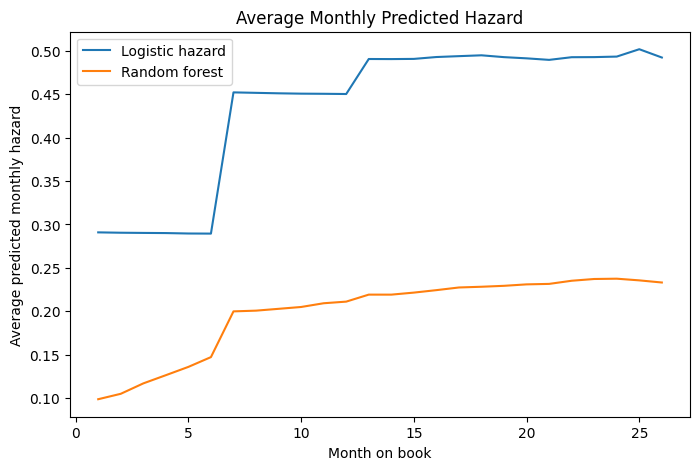

In [48]:
plot_hazard = (
    test_scored.groupby("month_on_book")[["pred_hazard_logit", "pred_hazard_rf"]]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 5))
plt.plot(plot_hazard["month_on_book"], plot_hazard["pred_hazard_logit"], label="Logistic hazard")
plt.plot(plot_hazard["month_on_book"], plot_hazard["pred_hazard_rf"], label="Random forest")
plt.xlabel("Month on book")
plt.ylabel("Average predicted monthly hazard")
plt.title("Average Monthly Predicted Hazard")
plt.legend()
plt.show()

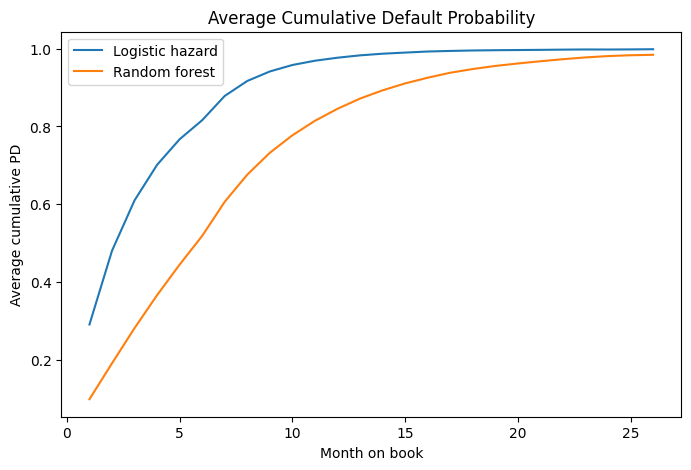

In [31]:
plot_cum_pd = (
    test_scored.groupby("month_on_book")[["cum_pd_logit", "cum_pd_rf"]]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 5))
plt.plot(plot_cum_pd["month_on_book"], plot_cum_pd["cum_pd_logit"], label="Logistic hazard")
plt.plot(plot_cum_pd["month_on_book"], plot_cum_pd["cum_pd_rf"], label="Random forest")
plt.xlabel("Month on book")
plt.ylabel("Average cumulative PD")
plt.title("Average Cumulative Default Probability")
plt.legend()
plt.show()

In [32]:
loan_12m = test_scored[test_scored["month_on_book"] == 12].copy()

print("Loans with 12-month horizon rows:", loan_12m["id"].nunique())
loan_12m[["id", "cum_pd_logit", "cum_pd_rf"]].head()

Loans with 12-month horizon rows: 9504


,id,cum_pd_logit,cum_pd_rf
215008,100001365,0.997173,0.905866
539498,100001532,0.955113,0.782240
62778,100002096,0.998837,0.870633
86881,100003912,0.983830,0.888514
866480,100005538,0.999107,0.941811


In [33]:
LGD = 0.60

loan_12m["ead_proxy"] = loan_12m["loan_amnt"]
loan_12m["expected_loss_12m_logit"] = loan_12m["cum_pd_logit"] * LGD * loan_12m["ead_proxy"]
loan_12m["expected_loss_12m_rf"] = loan_12m["cum_pd_rf"] * LGD * loan_12m["ead_proxy"]

loan_12m[[
    "id",
    "loan_amnt",
    "cum_pd_logit",
    "cum_pd_rf",
    "expected_loss_12m_logit",
    "expected_loss_12m_rf"
]].head()

,id,loan_amnt,cum_pd_logit,cum_pd_rf,expected_loss_12m_logit,expected_loss_12m_rf
215008,100001365,20000.0,0.997173,0.905866,11966.079170,10870.394702
539498,100001532,30000.0,0.955113,0.782240,17192.039620,14080.315245
62778,100002096,20000.0,0.998837,0.870633,11986.042222,10447.597700
86881,100003912,28500.0,0.983830,0.888514,16823.490827,15193.590911
866480,100005538,14400.0,0.999107,0.941811,8632.284084,8137.247631


In [34]:
funding_cost = 0.04
profit_margin = 0.03

loan_12m["el_rate_12m_logit"] = loan_12m["expected_loss_12m_logit"] / loan_12m["loan_amnt"]
loan_12m["el_rate_12m_rf"] = loan_12m["expected_loss_12m_rf"] / loan_12m["loan_amnt"]

loan_12m["required_rate_logit"] = funding_cost + profit_margin + loan_12m["el_rate_12m_logit"]
loan_12m["required_rate_rf"] = funding_cost + profit_margin + loan_12m["el_rate_12m_rf"]

loan_12m[[
    "id",
    "required_rate_logit",
    "required_rate_rf"
]].head()

,id,required_rate_logit,required_rate_rf
215008,100001365,0.668304,0.613520
539498,100001532,0.643068,0.539344
62778,100002096,0.669302,0.592380
86881,100003912,0.660298,0.603108
866480,100005538,0.669464,0.635087


In [35]:
loan_12m["risk_band_logit"] = pd.qcut(
    loan_12m["cum_pd_logit"],
    q=5,
    labels=["Very Low", "Low", "Medium", "High", "Very High"]
)

reserve_summary_logit = (
    loan_12m.groupby("risk_band_logit")
    .agg(
        loans=("id", "count"),
        avg_pd_12m=("cum_pd_logit", "mean"),
        total_expected_loss=("expected_loss_12m_logit", "sum"),
        avg_required_rate=("required_rate_logit", "mean"),
    )
    .reset_index()
)

reserve_summary_logit

,risk_band_logit,loans,avg_pd_12m,total_expected_loss,avg_required_rate
0,Very Low,1901,0.903110,1.640410e+07,0.611866
1,Low,1901,0.985197,1.559961e+07,0.661118
2,Medium,1900,0.995741,1.581871e+07,0.667444
3,High,1901,0.998983,1.634126e+07,0.669390
4,Very High,1901,0.999891,1.964303e+07,0.669935


In [36]:
loan_12m["risk_band_rf"] = pd.qcut(
    loan_12m["cum_pd_rf"],
    q=5,
    labels=["Very Low", "Low", "Medium", "High", "Very High"]
)

reserve_summary_rf = (
    loan_12m.groupby("risk_band_rf")
    .agg(
        loans=("id", "count"),
        avg_pd_12m=("cum_pd_rf", "mean"),
        total_expected_loss=("expected_loss_12m_rf", "sum"),
        avg_required_rate=("required_rate_rf", "mean"),
    )
    .reset_index()
)

reserve_summary_rf

,risk_band_rf,loans,avg_pd_12m,total_expected_loss,avg_required_rate
0,Very Low,1901,0.656380,1.040475e+07,0.463828
1,Low,1901,0.807047,1.316241e+07,0.554228
2,Medium,1900,0.874520,1.427445e+07,0.594712
3,High,1901,0.922686,1.603663e+07,0.623612
4,Very High,1901,0.965291,1.945196e+07,0.649174


In [37]:
test_scored_path = PROCESSED_DIR / "test_panel_scored.csv"
loan_12m_path = PROCESSED_DIR / "loan_level_12m_outputs.csv"
results_path = PROCESSED_DIR / "model_comparison_results.csv"

test_scored.to_csv(test_scored_path, index=False)
loan_12m.to_csv(loan_12m_path, index=False)
results_df.to_csv(results_path, index=False)

print(f"Saved scored panel to: {test_scored_path}")
print(f"Saved 12m loan outputs to: {loan_12m_path}")
print(f"Saved model comparison to: {results_path}")

Saved scored panel to: data/processed/test_panel_scored.csv
Saved 12m loan outputs to: data/processed/loan_level_12m_outputs.csv
Saved model comparison to: data/processed/model_comparison_results.csv


In [38]:
print("Model comparison:")
display(results_df)

print("\n12-month cumulative PD summary:")
display(pd_summary)

print("\nReserve summary (logistic hazard):")
display(reserve_summary_logit)

Model comparison:


,model,valid_roc_auc,valid_pr_auc,test_roc_auc,test_pr_auc
0,logistic_hazard,0.67341,0.014592,0.676487,0.009300
1,random_forest,0.65145,0.013210,0.670137,0.008597



12-month cumulative PD summary:


,month_on_book,avg_cum_pd_logit,avg_cum_pd_rf,loans
0,6,0.816005,0.518645,16402
1,12,0.976582,0.845182,9504
2,24,0.997657,0.980780,1103



Reserve summary (logistic hazard):


,risk_band_logit,loans,avg_pd_12m,total_expected_loss,avg_required_rate
0,Very Low,1901,0.903110,1.640410e+07,0.611866
1,Low,1901,0.985197,1.559961e+07,0.661118
2,Medium,1900,0.995741,1.581871e+07,0.667444
3,High,1901,0.998983,1.634126e+07,0.669390
4,Very High,1901,0.999891,1.964303e+07,0.669935


In [39]:
print("Actual monthly event rate:", y_test.mean())
print("Mean predicted hazard, logistic:", test_pred_hazard.mean())
print("Mean predicted hazard, RF:", test_pred_rf.mean())

Actual monthly event rate: 0.0045074236276504845
Mean predicted hazard, logistic: 0.3843274513956722
Mean predicted hazard, RF: 0.169417411001436


In [40]:
print(test_scored[["pred_hazard_logit", "pred_hazard_rf"]].describe())

       pred_hazard_logit  pred_hazard_rf
count      242267.000000   242267.000000
mean            0.384327        0.169417
std             0.163256        0.081865
min             0.000033        0.002863
25%             0.258382        0.106410
50%             0.372656        0.157940
75%             0.500334        0.222545
max             1.000000        0.555906
